# Output Based Pricing System Calculation
This script processes the Output Based Pricing System (OBPS) as an addition to the fixed cost of selected technologies.
The technologies and relations are adjustable and can be modified.
In this version, the processing is based on 'CO2_Emission', which represents emissions of CO2 (measured as carbon, ton C/kWyr).
The script calculates OBPS for two scenarios: Baseline and NetZero.


In [1]:

import pandas as pd

file_path = 'D:\Documentos\IESVic\MESSAGE_ix\message-ix\model\data_CA_provincial_calibrated_v1.xlsx'#'/home/jgmonroe/Documents/Energy_Models/message-ix/model/data_CA_provincial_calibrated_v1.xlsx'

# Read the required data
data_relation = pd.read_excel(file_path, sheet_name='relation_activity')

# Define the technologies and relations


#conditions_1 = (data_relation['technology'].isin(['oil_extr_1', 'coal_ppl','oil_extr_2', 'foil_ppl'])) & (data_relation['relation'] == 'CO2_cc') & (data_relation['node_rel'] == 'Alberta')
conditions_2= (data_relation['technology'].isin(['oil_extr_1', 'oil_extr_2', 'oil_extr_3', 'oil_extr_4', 'oil_extr_5','oil_extr_6', 'cement_CO2','coal_extr','gas_extr_1','gas_extr_2','gas_extr_3','gas_extr_4','gas_extr_5','gas_extr_6'])) & (data_relation['relation'] == 'CO2_Emission') & (data_relation['node_rel'] == 'Alberta')

# Filter the data based on the conditions
filtered_data = data_relation[conditions_2]


# Select the relevant columns
result = filtered_data[['technology', 'value', 'node_rel', 'year_act']]

# Save the result to a new Excel file
result.to_csv('filtered_data.csv', index=False)




# Baseline Scenario based on Energy Future 2023

In [2]:
result.loc[:,'Emission Intensity Reduction_baseline'] = 0.0
for index, row in result.iterrows():
	if 2020 < row['year_act'] < 2055:
		previous_year_value = result.loc[(result['technology'] == row['technology']) & (result['year_act'] == row['year_act'] - 5), 'Emission Intensity Reduction_baseline'].values
		if len(previous_year_value) > 0:
			result.loc[index, 'Emission Intensity Reduction_baseline'] += previous_year_value[0] + 3.33/100

result.to_csv('filtered_data.csv', index=False)

C:\Users\crist\AppData\Local\Temp\ipykernel_2100\4027745382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result.loc[:,'Emission Intensity Reduction_baseline'] = 0.0


In [3]:
#Emission intensity standard_Baseline Canada Scenario 
result['Emission intensity standard_Baseline Canada Scenario'] = 0.0

# Calculate the 'Emission intensity standard_Baseline Canada Scenario' values
for index, row in result.iterrows():
	if row['year_act'] > 2020:
		value_cal = result.loc[(result['technology'] == row['technology']) & (result['year_act'] == 2015), 'value']
		if not value_cal.empty:
			result.at[index, 'Emission intensity standard_Baseline Canada Scenario'] = row['value'] - row['Emission Intensity Reduction_baseline'] * value_cal.values[0]
		else:
			value_cal = result.loc[(result['technology'] == row['technology']) & (result['year_act'] == 2020), 'value']
			result.at[index, 'Emission intensity standard_Baseline Canada Scenario'] = row['value'] - row['Emission Intensity Reduction_baseline'] * value_cal.values[0]

result.to_csv('filtered_data.csv', index=False)

C:\Users\crist\AppData\Local\Temp\ipykernel_2100\3545269145.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['Emission intensity standard_Baseline Canada Scenario'] = 0.0


In [4]:
#Payable emission intensity_Baseline scenario
#based on documentation: CO2_Emission is Emissions of CO2 (weight as carbon, ton C/kWyr)
result.loc[:, 'Payable emission intensity_Baseline scenario'] = 0.0

for index, row in result.iterrows():
	if row['year_act'] > 2020:
		result.loc[index, 'Payable emission intensity_Baseline scenario']= row['value']-row['Emission intensity standard_Baseline Canada Scenario']
		
# Save the updated data back to the same CSV file
result.to_csv('filtered_data.csv', index=False)

C:\Users\crist\AppData\Local\Temp\ipykernel_2100\3502897552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result.loc[:, 'Payable emission intensity_Baseline scenario'] = 0.0


In [6]:
#carbon price ($ CAD/tonne CO2), CAD 1=US 0.73
rate= 0.73
#carbon cost_Baseline Canada scenario ($ USD/tonne CO2)*(ton C/kWyr) so the final unit is (USD/kwyr)
result.loc[:, 'carbon cost_Baseline Canada scenario'] =0.0

for index, row in result.iterrows():
	if row['year_act']== 2025:
		result.loc[index,'carbon cost_Baseline Canada scenario']= row['Payable emission intensity_Baseline scenario']*rate*125
	elif row['year_act']> 2025:
		result.loc[index,'carbon cost_Baseline Canada scenario']= row['Payable emission intensity_Baseline scenario']*rate*170


result.to_csv('filtered_data.csv', index=False)


In [7]:
# Year 2055 and 2060 adjustment
for index, row in result.iterrows():
	if row['year_act'] > 2050:
		value_to_assign = result.loc[(result['technology'] == row['technology']) & (result['year_act'] == 2050), 'carbon cost_Baseline Canada scenario'].values
		if len(value_to_assign) > 0:
			result.at[index, 'carbon cost_Baseline Canada scenario'] = value_to_assign[0]
			
result.to_csv('filtered_data.csv', index=False)

In [8]:
#add to fix_cost (USD/kw)
data_fixcost = pd.read_excel(file_path, sheet_name='fix_cost')


# Merge the dataframes on 'technology' and 'year' columns
merged_data = pd.merge(data_fixcost, result[['technology', 'year_act', 'carbon cost_Baseline Canada scenario']],
					   left_on=['technology', 'year_act'],
					   right_on=['technology', 'year_act'],
					   how='left')

# Update the 'value' column in fix_cost by adding the 'payable cost' from filtered_data

merged_data['value'] = merged_data['value'] + merged_data['carbon cost_Baseline Canada scenario'].fillna(0)

merged_data.drop(columns=['carbon cost_Baseline Canada scenario'], inplace=True)

# Save the updated fix_cost data to a new CSV file
merged_data.to_csv('updated_obps_baseline_fix_cost.csv', index=False)


In [9]:
data_fixcost.to_csv('base_fix_cost.csv')

In [9]:
merged_data["year_vtg"]

0         2010
1         2015
2         2020
3         2025
4         2030
          ... 
134857    2040
134858    2045
134859    2050
134860    2055
134861    2060
Name: year_vtg, Length: 134862, dtype: int64

# NetZero Scenario based on Energy Future 2023

In [10]:

result = filtered_data[['technology', 'value', 'node_rel', 'year_act']]
#Emission Intensity Reduction_Net Zero Scenario
#A 2% yearly tightening rate on emissions intensity is applied from 2023 to 2050

result.loc[:,'Emission Intensity Reduction_Net Zero Scenario']=0.0

for index, row in result.iterrows():
	if 2055> row['year_act'] >2020:
		result.loc [index, 'Emission Intensity Reduction_Net Zero Scenario'] = (row['year_act']-2022)*0.02
result.to_csv('new_NZero.csv', index=False)



C:\Users\crist\AppData\Local\Temp\ipykernel_2100\12080921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result.loc[:,'Emission Intensity Reduction_Net Zero Scenario']=0.0


In [11]:
#Emission intensity standard_Net zero
result.loc[:,'Emission intensity standard_Net zero']=0.0
for index, row in result.iterrows():
	if 2055> row['year_act'] >2020:
		result.loc[index, 'Emission intensity standard_Net zero']= row['value']*(1-row['Emission Intensity Reduction_Net Zero Scenario'])
result.to_csv('new_NZero.csv', index=False)

C:\Users\crist\AppData\Local\Temp\ipykernel_2100\1515967461.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result.loc[:,'Emission intensity standard_Net zero']=0.0


In [12]:
#Payable emission intensity_Net zero
result.loc[:,'Payable emission intensity_Net zero']=0.0
for index, row in result.iterrows():
	if 2055> row['year_act'] >2020:
		result.loc[index,'Payable emission intensity_Net zero']= (row['value']-row['Emission intensity standard_Net zero'])
result.to_csv('new_NZero.csv', index=False)

C:\Users\crist\AppData\Local\Temp\ipykernel_2100\4093242355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result.loc[:,'Payable emission intensity_Net zero']=0.0


In [13]:
#carbon cost_NetZero
rate= 0.73
#carbon cost_Baseline Canada scenario ($ USD/tonne CO2)*(ton C/kWyr) so the final unit is (USD/kwyr)
result.loc[:, 'carbon cost_Net zero scenario'] =0.0

for index, row in result.iterrows():
	if row['year_act']== 2025:
		result.loc[index,'carbon cost_Net zero scenario']= row['Payable emission intensity_Net zero']*rate*125
	elif row['year_act']> 2025:
		result.loc[index,'carbon cost_Net zero scenario']= row['Payable emission intensity_Net zero']*rate*170

result.to_csv('new_NZero.csv', index=False)

C:\Users\crist\AppData\Local\Temp\ipykernel_2100\1882820409.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result.loc[:, 'carbon cost_Net zero scenario'] =0.0


In [14]:
# Year 2055 and 2060 adjustment
for index, row in result.iterrows():
	if row['year_act'] > 2050:
		value_to_assign = result.loc[(result['technology'] == row['technology']) & (result['year_act'] == 2050), 'carbon cost_Net zero scenario'].values
		if len(value_to_assign) > 0:
			result.at[index, 'carbon cost_Net zero scenario'] = value_to_assign[0]
			
result.to_csv('new_NZero.csv', index=False)

In [15]:
#add to fix_cost (USD/kw)
data_fixcost = pd.read_excel(file_path, sheet_name='fix_cost')

# Merge the dataframes on 'technology' and 'year' columns
NetZero_merged_data = pd.merge(data_fixcost, result[['technology', 'year_act', 'carbon cost_Net zero scenario']],
					left_on=['technology', 'year_act'],
					right_on=['technology', 'year_act'],
					how='left')

# Update the 'value' column in fix_cost by adding the 'payable cost' from filtered_data
NetZero_merged_data['value'] = NetZero_merged_data['value'] + NetZero_merged_data['carbon cost_Net zero scenario'].fillna(0)

NetZero_merged_data.drop(columns=['carbon cost_Net zero scenario'], inplace=True)

NetZero_merged_data.to_csv('updated_obps_NetZero_fix_cost.csv', index=False)


# Generate Plots


In [16]:
#updated_obps_baseline_fix_cost.csv
#updated_obps_NetZero_fix_cost.csv
#data_fixcost
import pandas as pd

tech_list= ['oil_extr_1', 'oil_extr_2', 'oil_extr_3', 'oil_extr_4', 'oil_extr_5','oil_extr_6', 'cement_CO2','coal_extr','gas_extr_1','gas_extr_2','gas_extr_3','gas_extr_4','gas_extr_5','gas_extr_6']

#file_path = 'data_CA_provincial_reference_v1.xlsx'
data_fixcost = pd.read_excel(file_path, sheet_name='fix_cost')
df_base = merged_data
df_NetZero= NetZero_merged_data


data_fixcost_ab = data_fixcost[data_fixcost['node_loc'] == 'Alberta']
df_base_ab = df_base[df_base['node_loc'] == 'Alberta']
df_NetZero_ab = df_NetZero[df_NetZero['node_loc'] == 'Alberta']

# Merge the DataFrames on the year and technology columns
merged_df = data_fixcost_ab.merge(df_base_ab, on=['year_act', 'technology'], suffixes=('_1', '_2'))
merged_df = merged_df.merge(df_NetZero_ab, on=['year_act', 'technology'], suffixes=('', '_3'))

In [17]:
tech_list

['oil_extr_1',
 'oil_extr_2',
 'oil_extr_3',
 'oil_extr_4',
 'oil_extr_5',
 'oil_extr_6',
 'cement_CO2',
 'coal_extr',
 'gas_extr_1',
 'gas_extr_2',
 'gas_extr_3',
 'gas_extr_4',
 'gas_extr_5',
 'gas_extr_6']

In [18]:
tech_dict_oil = {'oil_extr_1': "conv. oil",
 'oil_extr_2': "conv. oil",
 'oil_extr_3': "conv. oil",
 'oil_extr_4': "non-conv. oil",
 'oil_extr_5': "non-conv. oil",
 'oil_extr_6': "non-conv. oil"}
tech_dict_gas = {'gas_extr_1': "conv. gas",
 'gas_extr_2': "conv. gas",
 'gas_extr_3': "conv. gas",
 'gas_extr_4': "non-conv. gas",
 'gas_extr_5': "non-conv. gas",
 'gas_extr_6': "non-conv. gas"}

tech_colors = {"conv. gas": "blue",
               "non-conv. gas": "red",
               "conv. oil": "black",
               "non-conv. oil": "grey"}


In [19]:
merged_df = merged_df[merged_df['year_vtg'] >=2020]

In [20]:
# Plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib import colormaps
from functools import reduce


conversion_factor = 1 / 31.536
# Initialize an empty DataFrame to store the results
result_list = []
handles = []

for tech in tech_dict_gas.keys():
	# Filter the merged dataframe for each technology
	tech_df = merged_df[merged_df['technology'] == tech]
	
	# Add this tech's data to the result df
	result_list.append(tech_df)

result_df = reduce(lambda x,y: pd.concat([x,y]), result_list)
result_df["technology"] = [tech_dict_gas[tech] for tech in result_df['technology'].values]


baseline_df = result_df.groupby(['technology', 'year_act'])['value_2'].mean().reset_index()
netzero_df = result_df.groupby(['technology', 'year_act'])['value'].mean().reset_index()

##########################################################################################
fig = go.Figure(layout_yaxis_range=[0,1.5])

# Iterate through each unique technology
'''
for tech in baseline_df["technology"].unique():
    data = baseline_df[baseline_df["technology"] == tech]
    fig.add_trace(go.Scatter(x=data["year_act"],
                            y=data.iloc[:,-1] * conversion_factor,
                            mode="lines",
                            line={"dash": "solid", "color": tech_colors[tech]},
                            name=f"Baseline -- {tech}"))
'''
for tech in netzero_df["technology"].unique():
    data = netzero_df[netzero_df["technology"] == tech]
    fig.add_trace(go.Scatter(x=data["year_act"],
                            y=data.iloc[:,-1] * conversion_factor,
                            mode="lines",
                            line={"dash": "dashdot", "color": tech_colors[tech]},
                            name=f"{tech}"))

fig.update_layout(title='Adjustment in Fixed Costs after OBPS Policy - Oil Technologies',
                  xaxis_title='Year',
                  yaxis_title='Fixed cost [USD/GJ]',
                  legend_title='Scenario -- Technology',
                  template='plotly_white')
fig.show()

#fig.write_image("Plot.png")





In [21]:
with pd.ExcelWriter("OBPS_numbers.xlsx", mode='w') as writer:
    baseline_df.to_excel(writer, sheet_name="Baseline")
    netzero_df.to_excel(writer, sheet_name="Netzero")

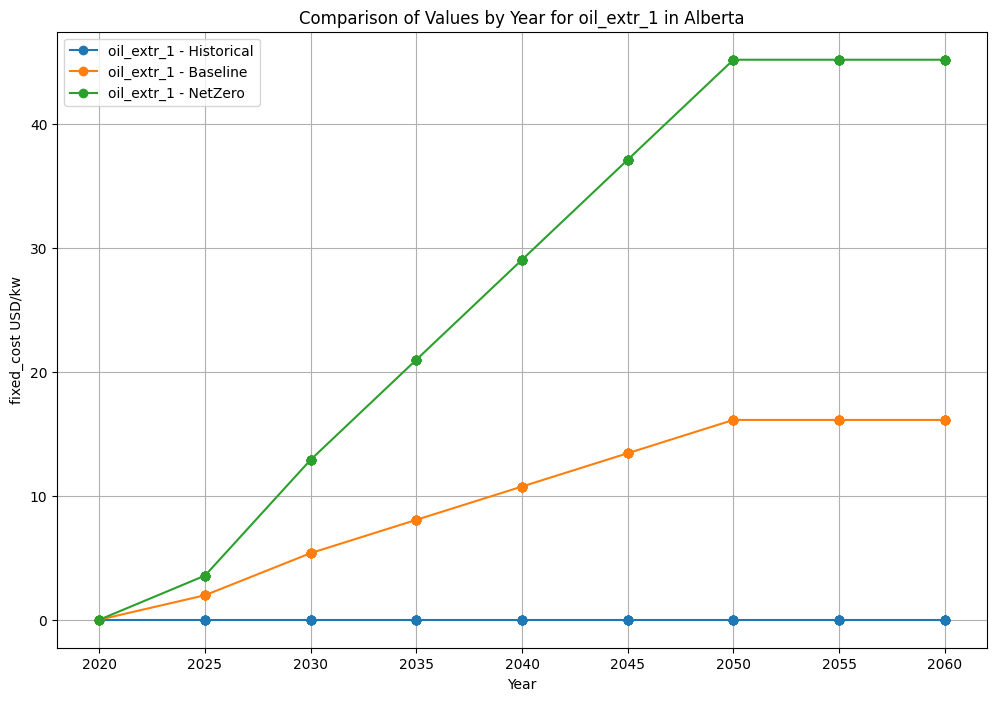

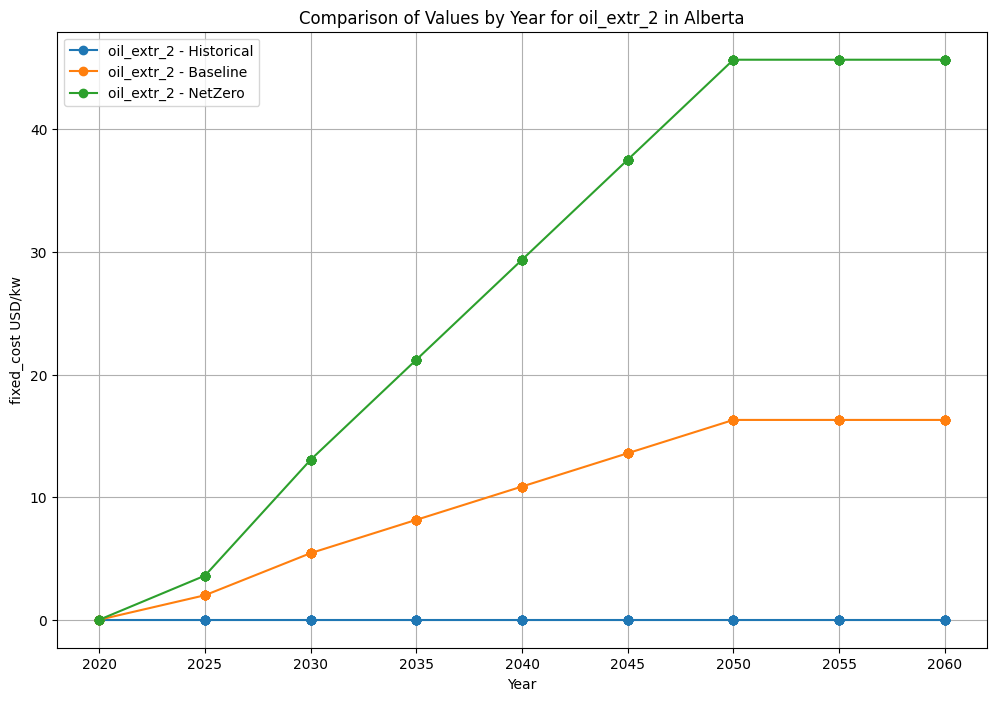

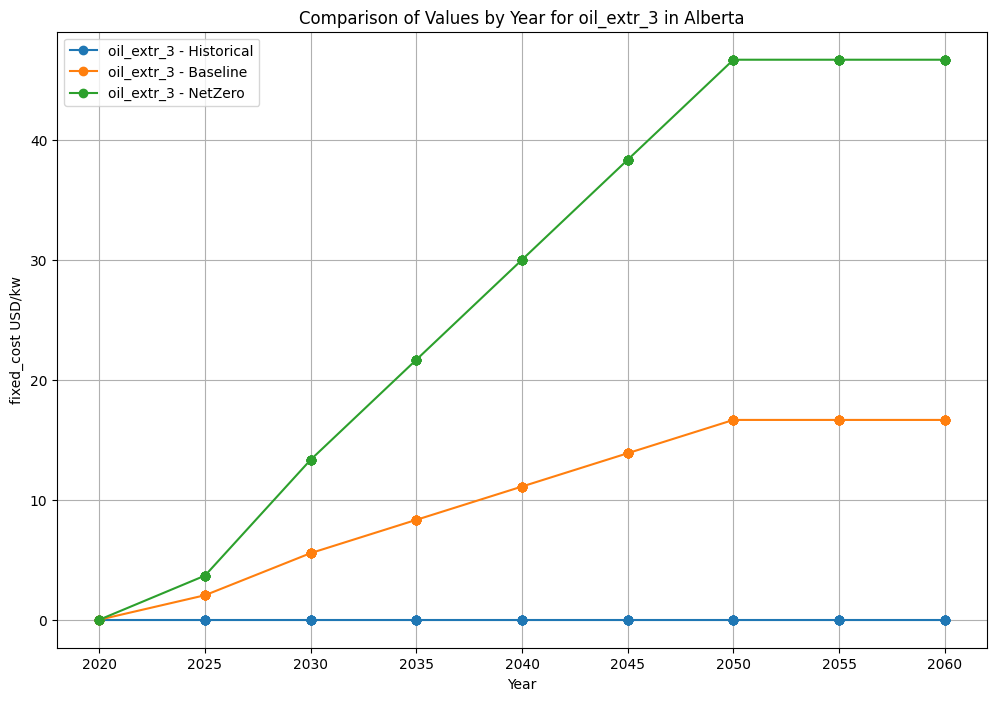

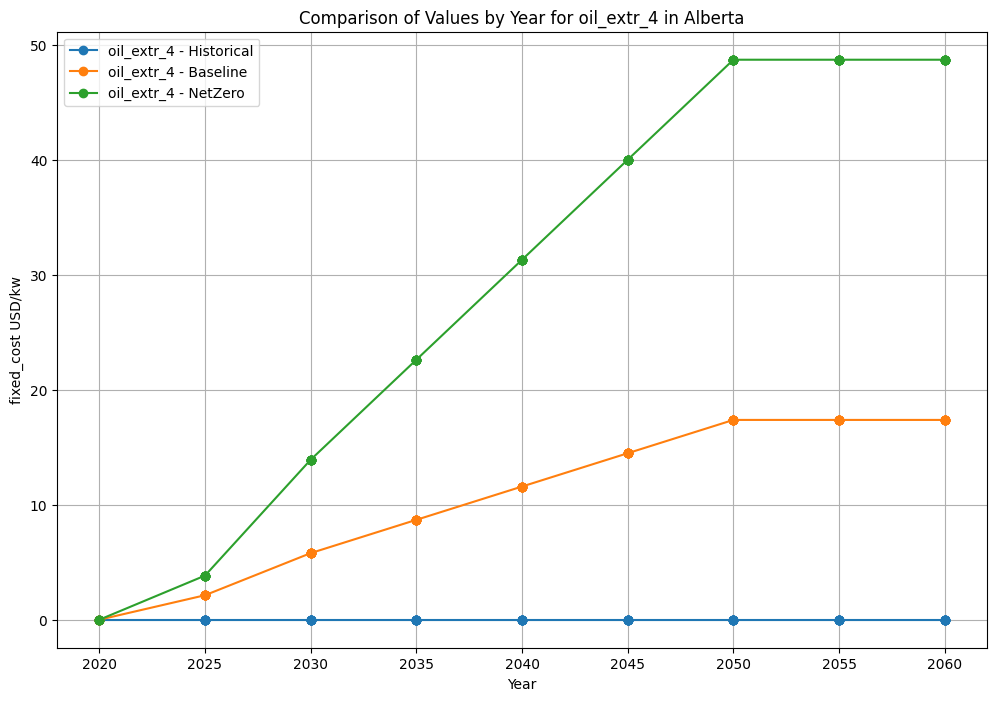

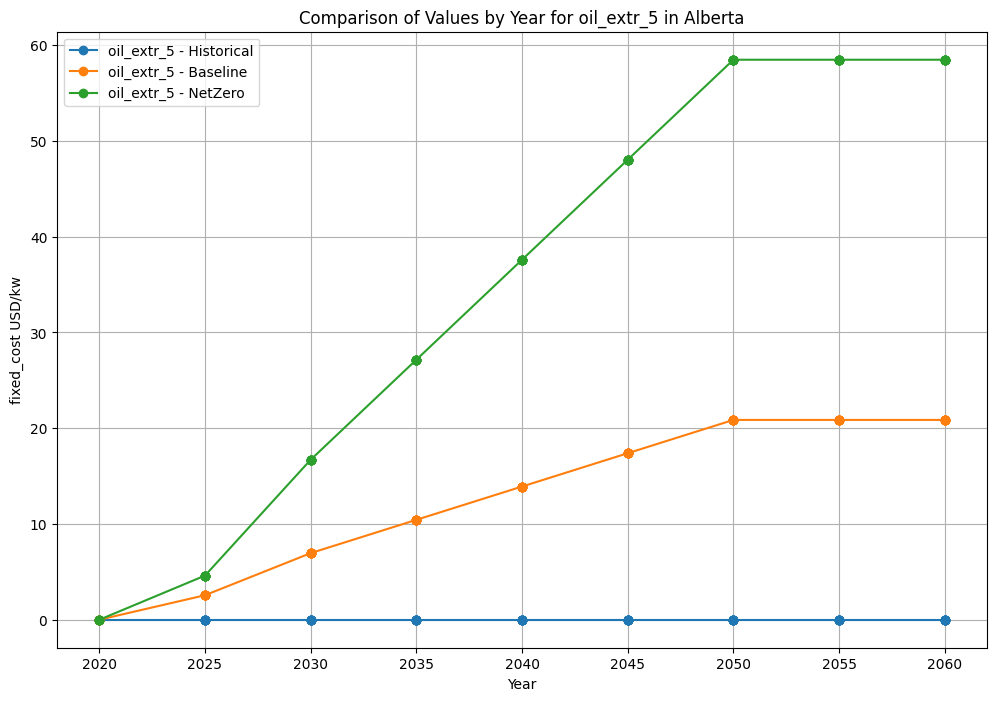

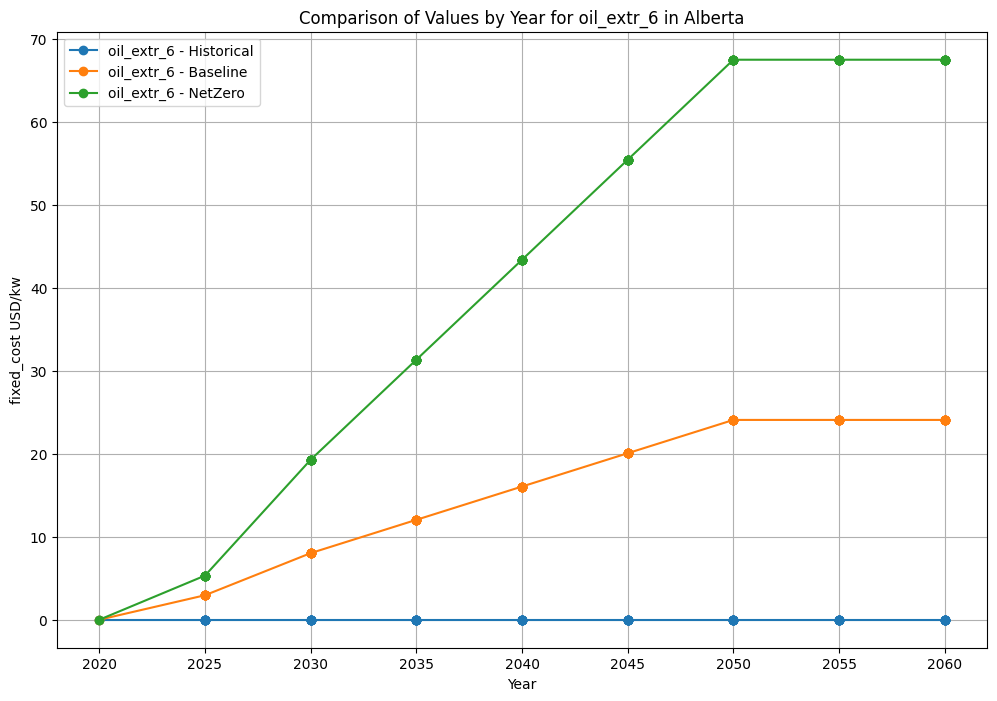

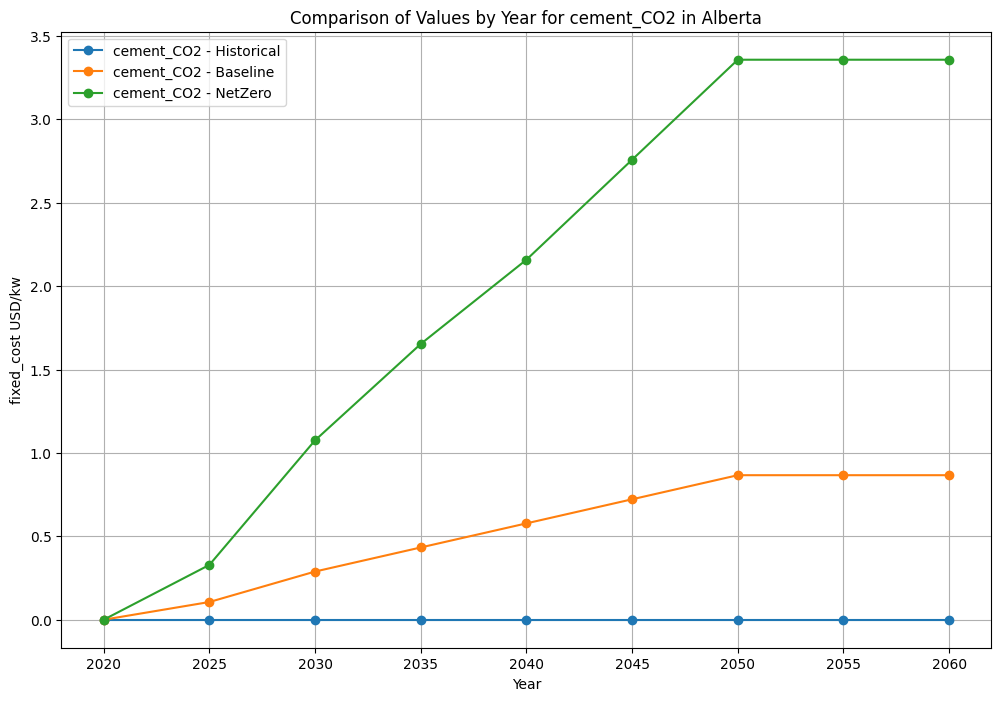

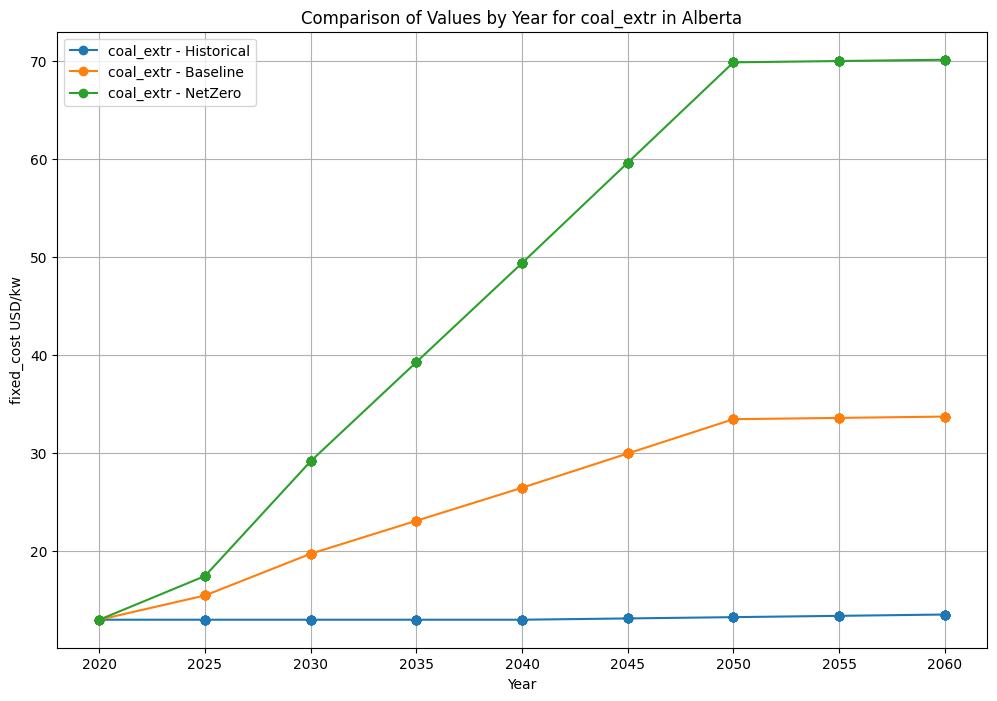

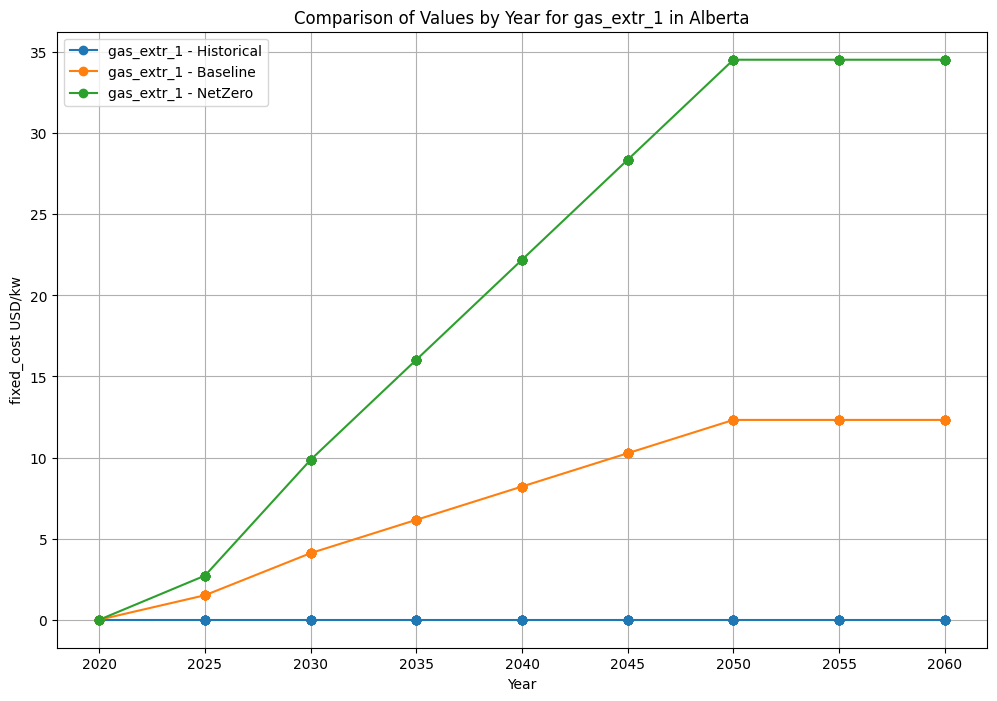

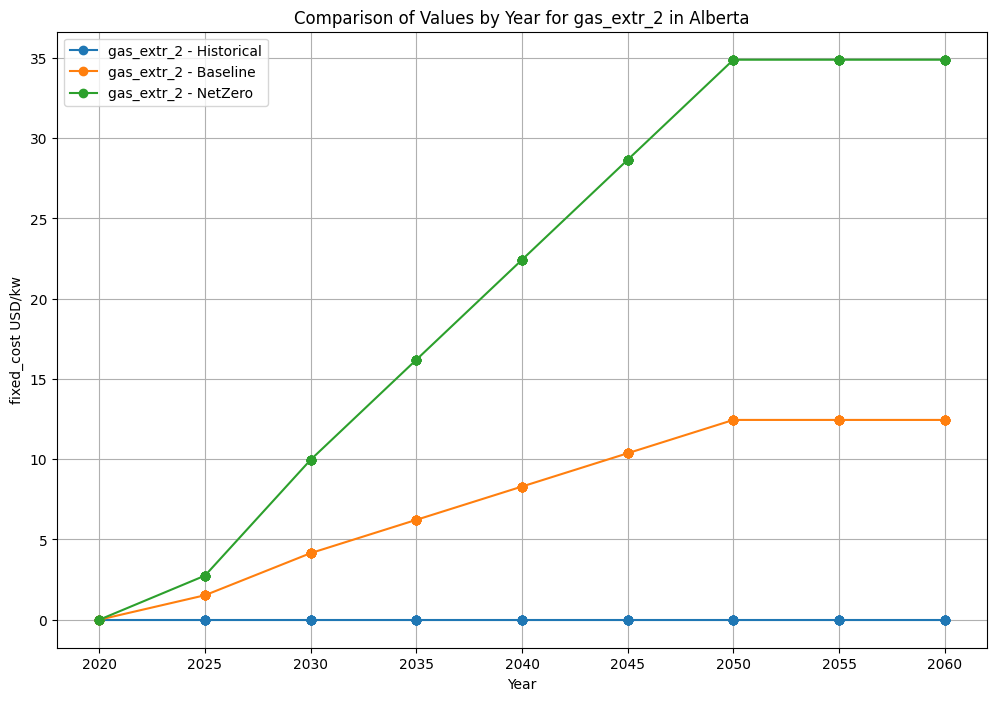

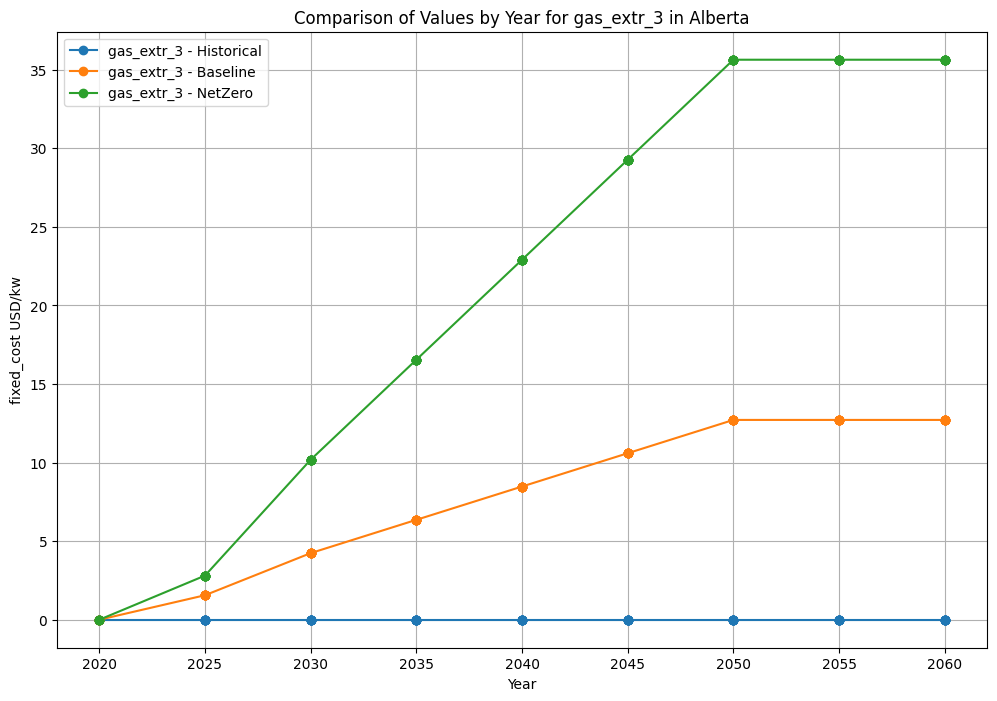

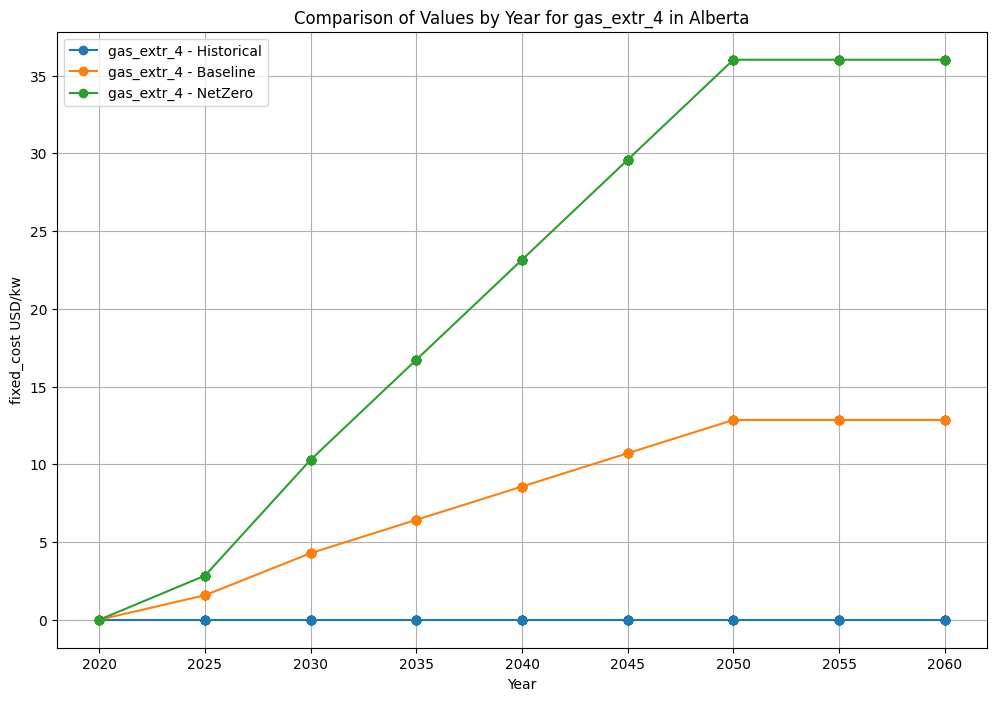

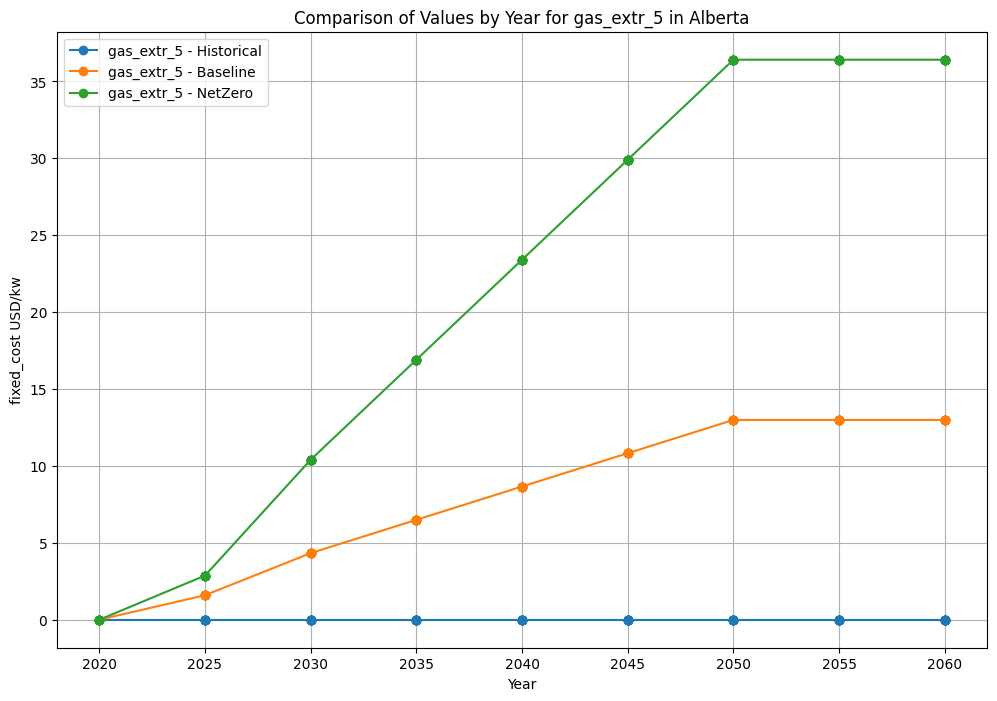

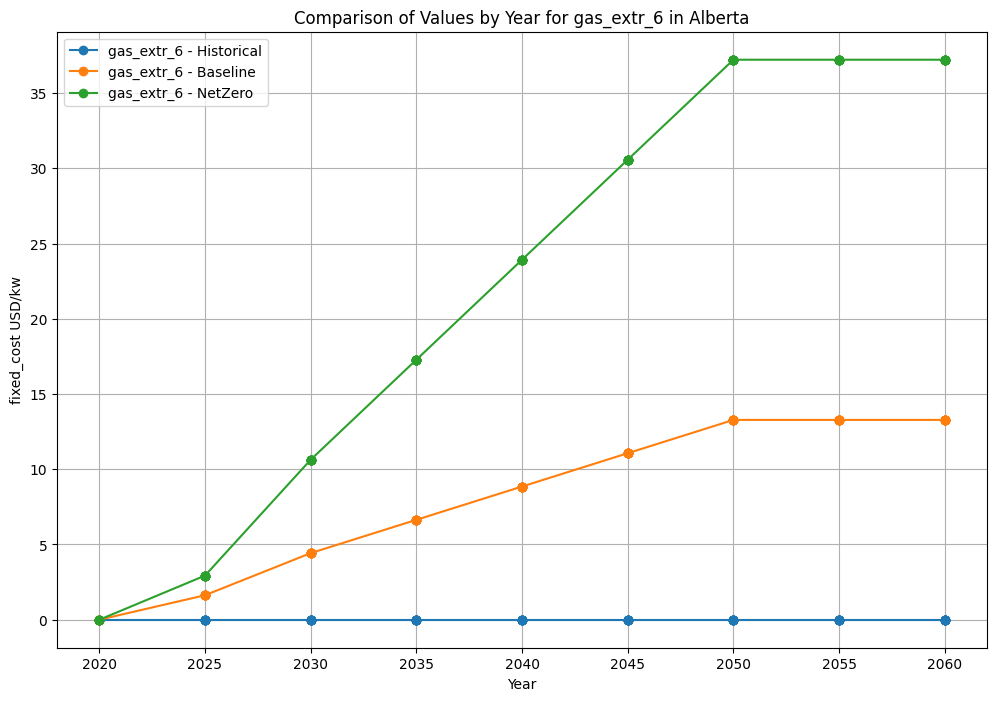

In [22]:
for tech in tech_list:
	plt.figure(figsize=(12, 8))
	
	tech_df = merged_df[merged_df['technology'] == tech]
	
	plt.plot(tech_df['year_act'], tech_df['value_1'], label=f'{tech} - Historical', marker='o')
	plt.plot(tech_df['year_act'], tech_df['value_2'], label=f'{tech} - Baseline', marker='o')
	plt.plot(tech_df['year_act'], tech_df['value'], label=f'{tech} - NetZero', marker='o')
	
	plt.xlabel('Year')
	plt.ylabel('fixed_cost USD/kw')
	plt.title(f'Comparison of Values by Year for {tech} in Alberta')
	plt.legend()
	plt.grid(True)
	
	# Save the plot as an image file
	plt.savefig(f'obps_plot_{tech}.jpg')
	
	plt.show()
